# Setup

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Carregando e Visualizando os Dados

In [2]:
df = pd.read_csv('data/csv-3.csv')
df.head()

,Unnamed: 0,Cód Mun. (IBGE),Município,UF,Região,População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
0,1,1100031,Cabixi,RO,Norte,5363,2022,0.650,0.650,0.559
1,2,1100072,Corumbiara,RO,Norte,7519,2022,0.613,0.630,0.473
2,3,1100148,Nova Brasilândia D'Oeste,RO,Norte,15679,2022,0.643,0.664,0.524
3,4,1100262,Rio Crespo,RO,Norte,3471,2022,0.643,0.637,0.513
4,5,1100379,Alto Alegre dos Parecis,RO,Norte,11479,2022,0.592,0.603,0.443


## Descrição Geral 

In [4]:
df.describe()

,Unnamed: 0,Cód Mun. (IBGE),População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
count,2707.000000,2.707000e+03,2707.000000,2707.0,2704.000000,2704.000000,2704.000000
mean,1354.000000,3.126497e+06,8686.320281,2022.0,0.639421,0.618748,0.537298
std,781.587914,9.067145e+05,7845.450261,0.0,0.068926,0.076516,0.090289
min,1.000000,1.100031e+06,833.000000,2022.0,0.418000,0.400000,0.207000
25%,677.500000,2.413330e+06,3743.000000,2022.0,0.584000,0.555000,0.471000
50%,1354.000000,3.120870e+06,6133.000000,2022.0,0.636000,0.615000,0.533000
75%,2030.500000,3.551158e+06,10881.500000,2022.0,0.699000,0.682000,0.604000
max,2707.000000,5.222302e+06,91767.000000,2022.0,0.806000,0.848000,0.778000


## Descrição da População

In [15]:
df['População'].describe().round().to_frame()

,População
count,2707.0
mean,8686.0
std,7845.0
min,833.0
25%,3743.0
50%,6133.0
75%,10882.0
max,91767.0


## 1. Tabela de Estatísticas Descritivas da População

In [31]:
df_medidas = pd.DataFrame([
    {
        'Média':df['População'].mean(),
        'Mediana':df['População'].median(),
        'Moda':[df['População'].mode()[i] for i in range(len(df['População'].mode()))],
        'Desvio Padrão':df['População'].std(),
        'Variância':(df['População'].std())**2,
        'Mínimo':df['População'].min(),
        'Máximo':df['População'].max(),
        'Total':df['População'].count()
     }
])
df_medidas.round().head()

,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Máximo,Total
0,8686.0,6133.0,"[3747, 4127]",7845.0,61551090.0,833,91767,2707


## 2. Agrupamento de Dados por UF

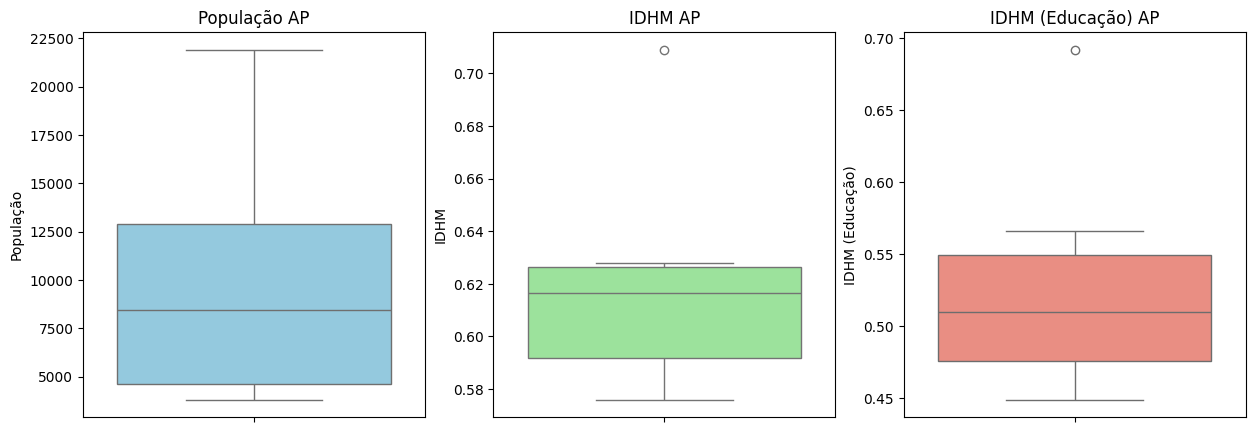

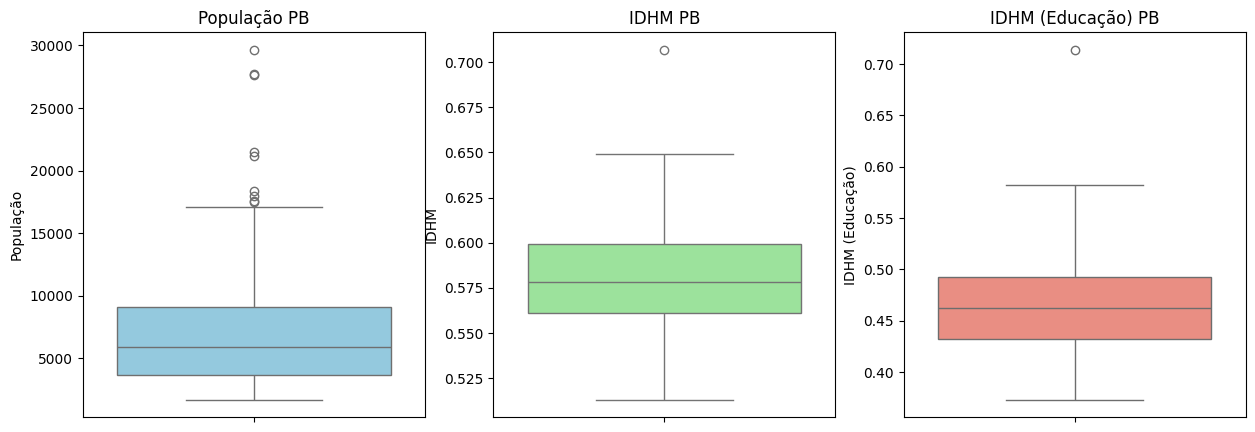

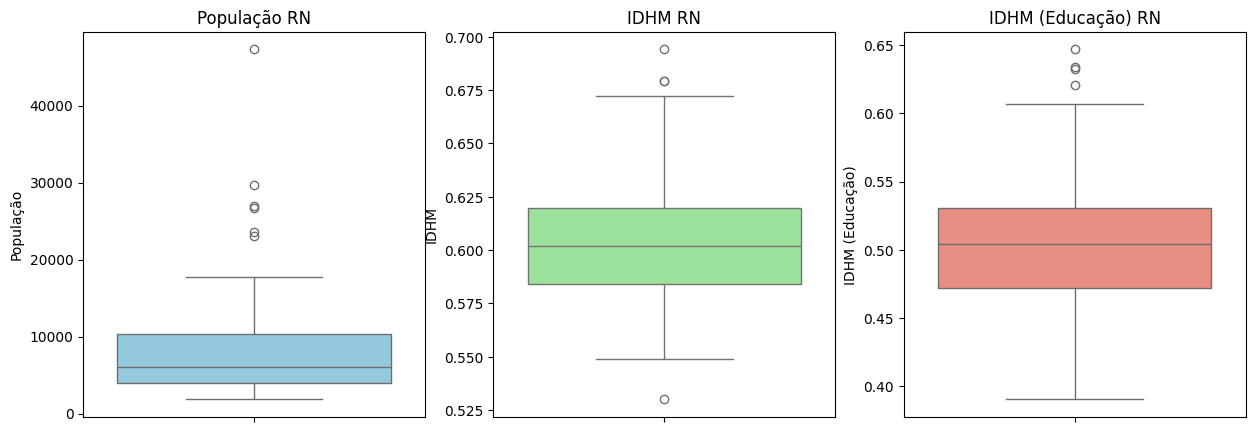

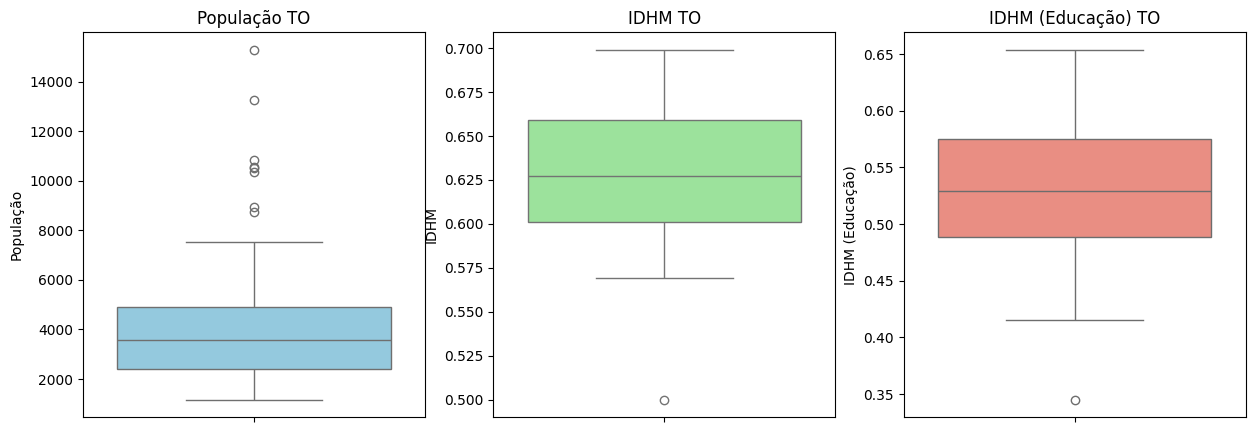

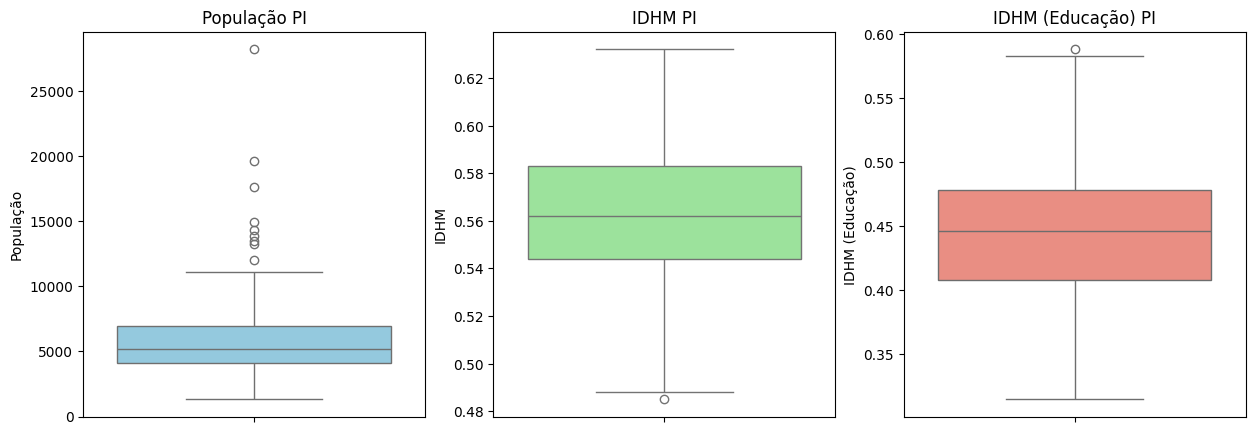

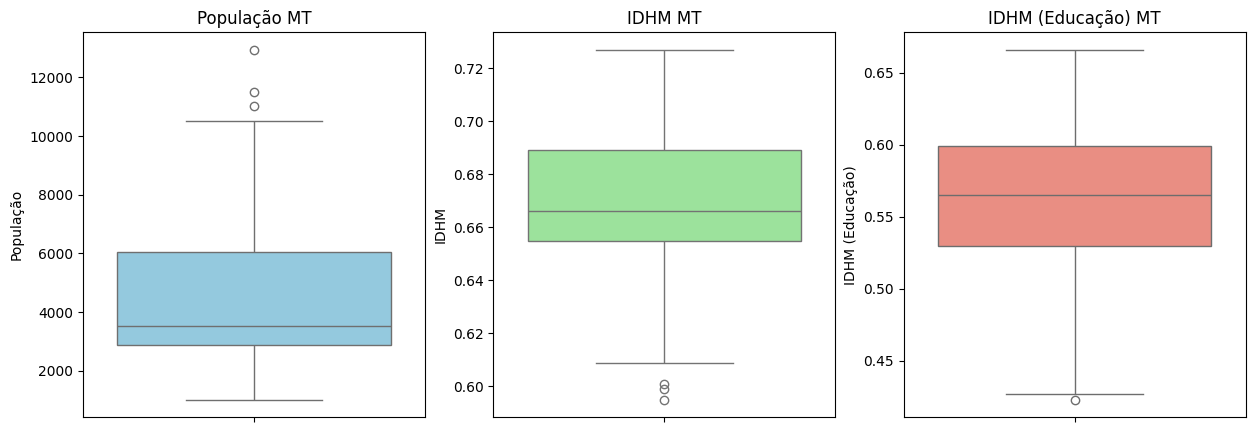

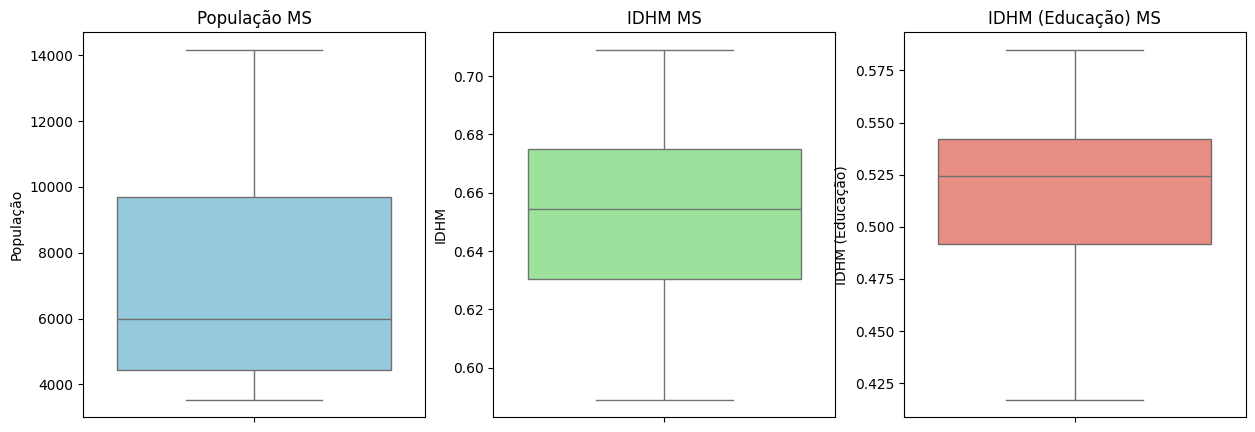

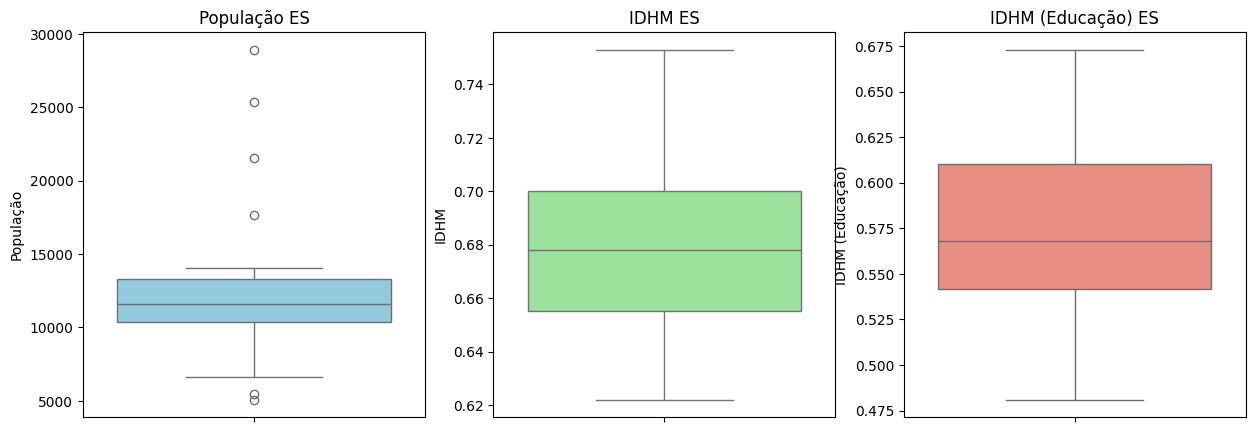

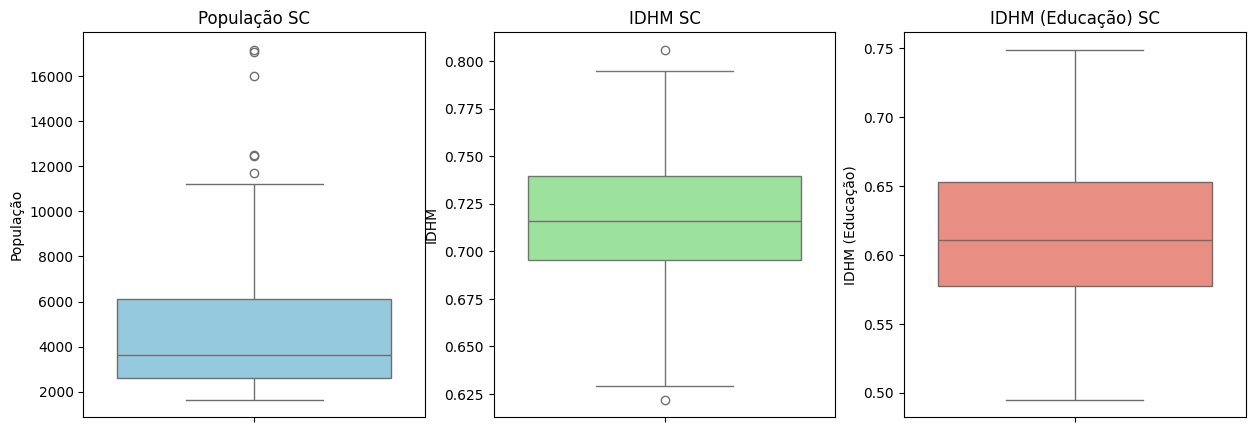

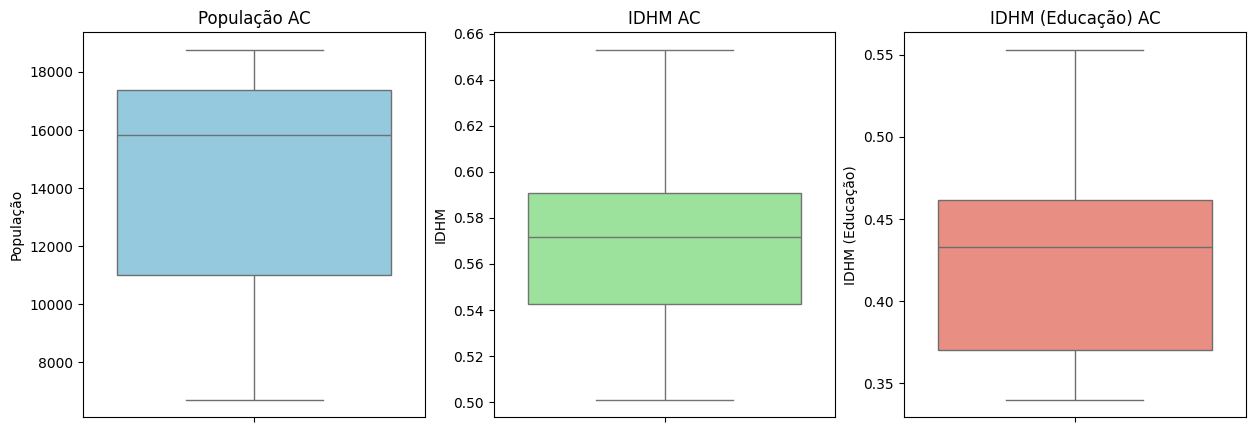

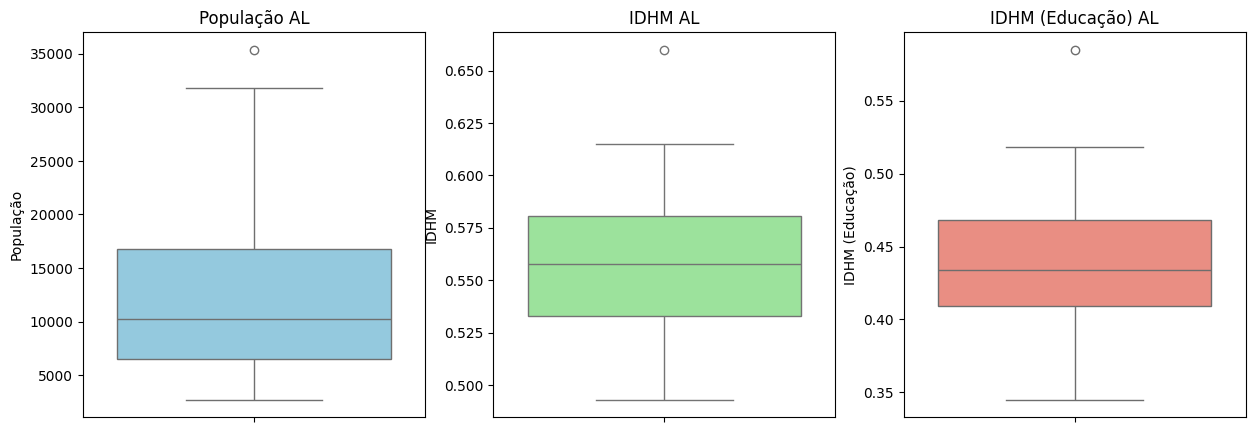

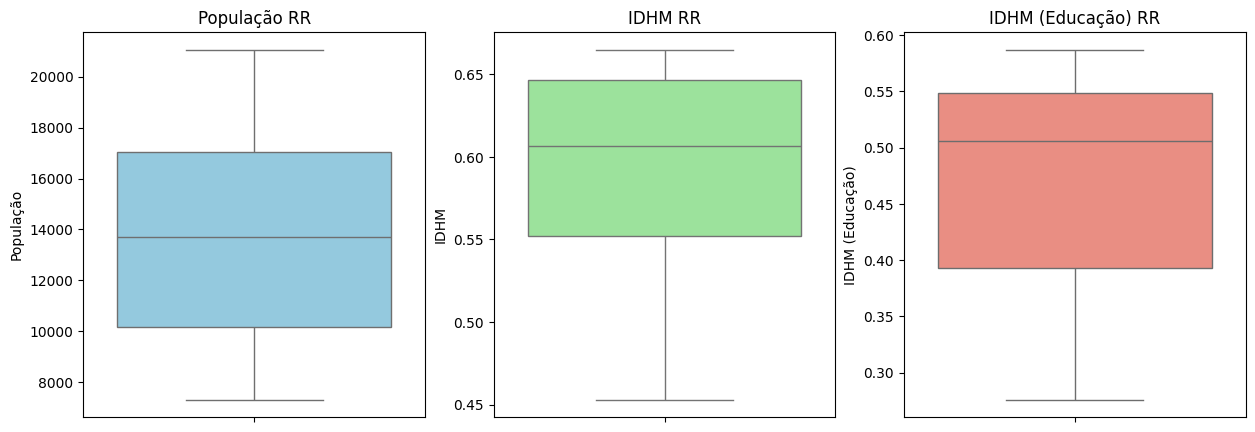

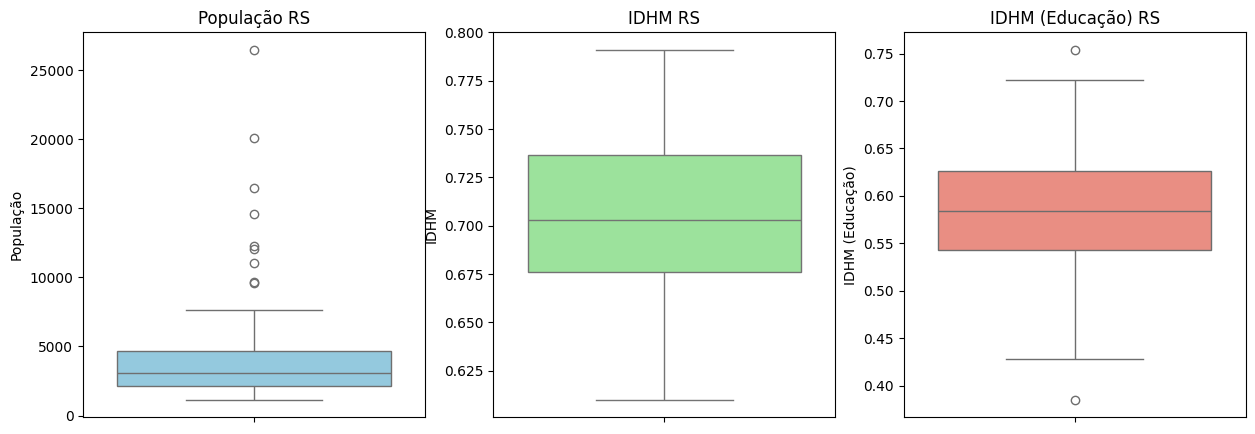

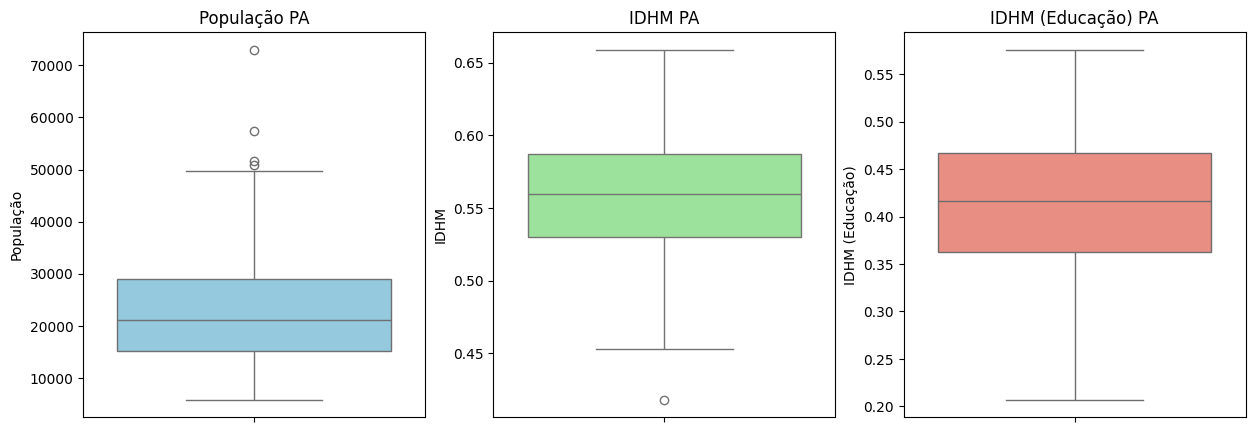

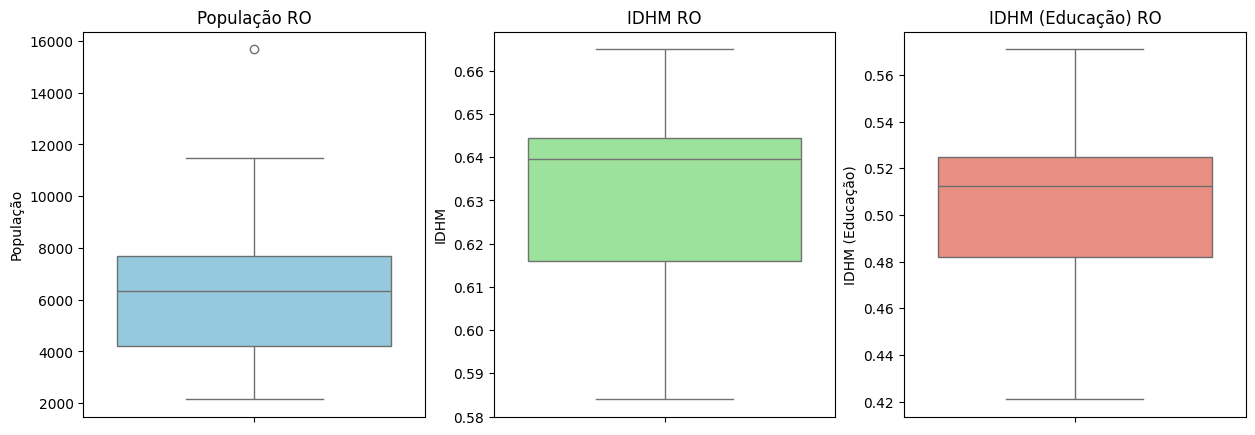

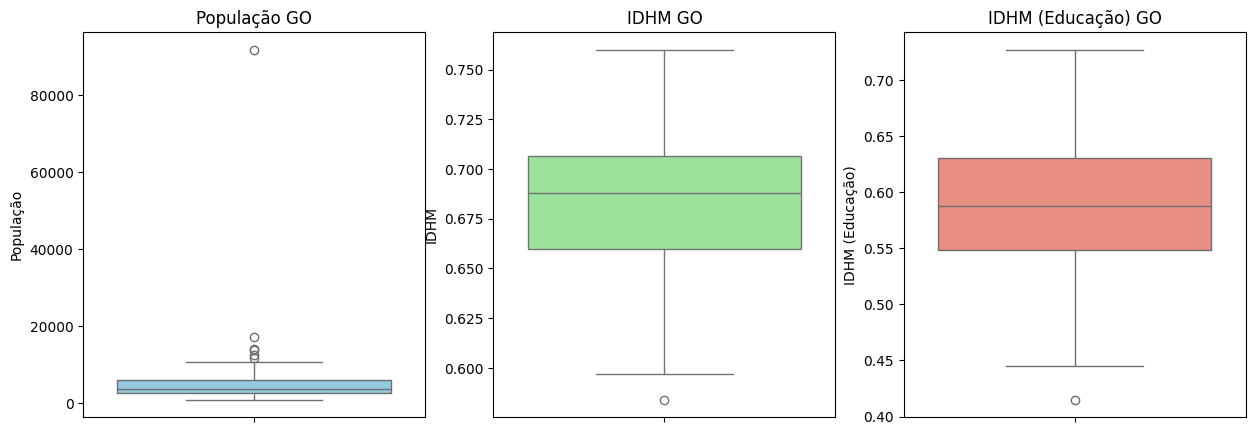

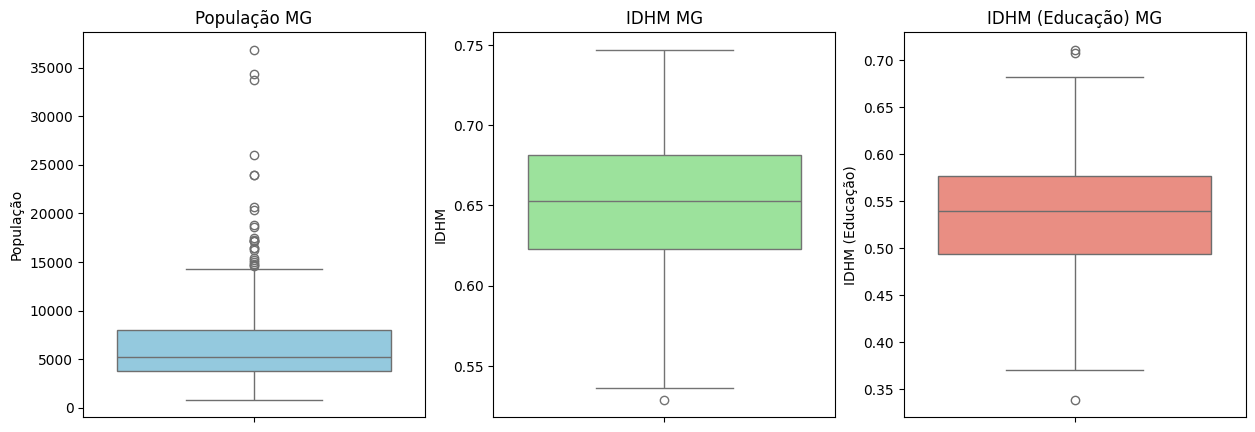

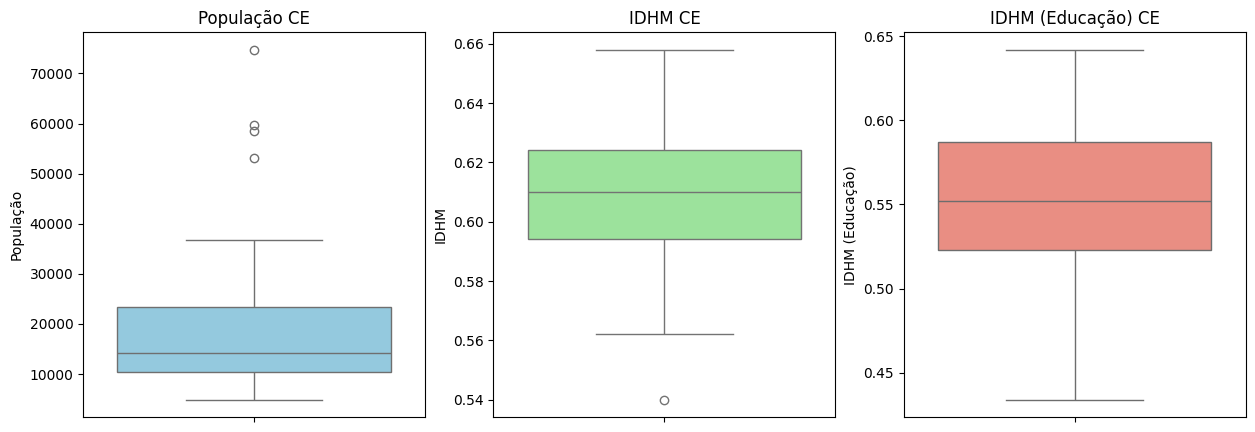

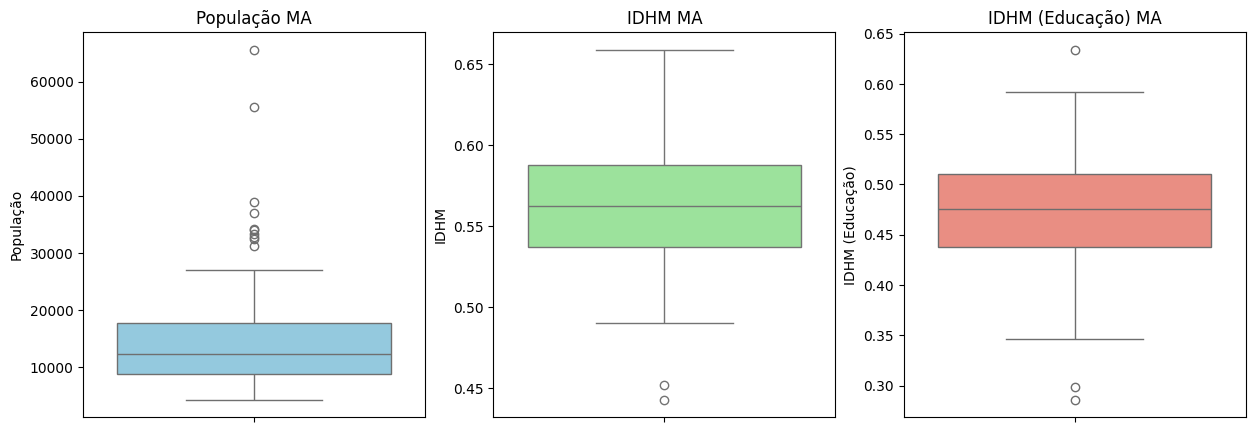

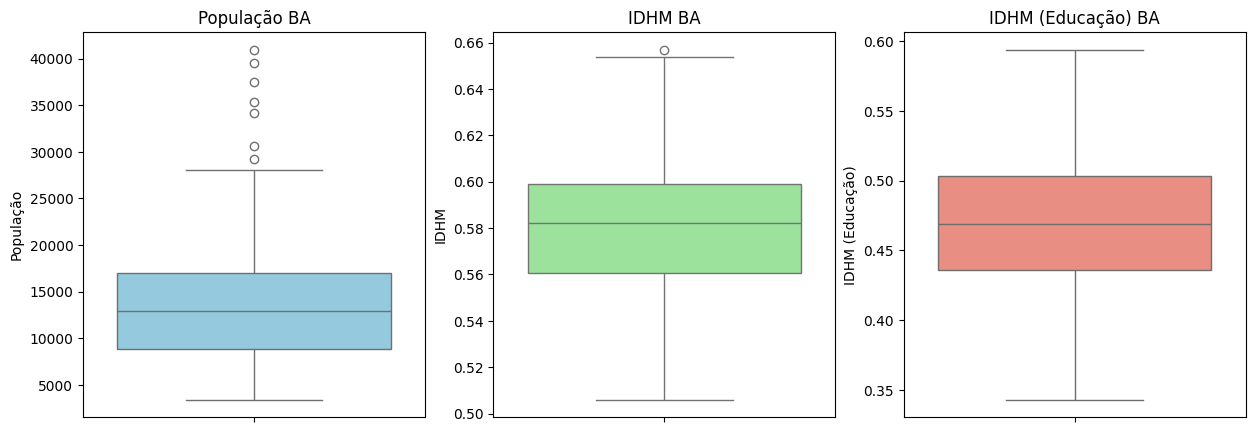

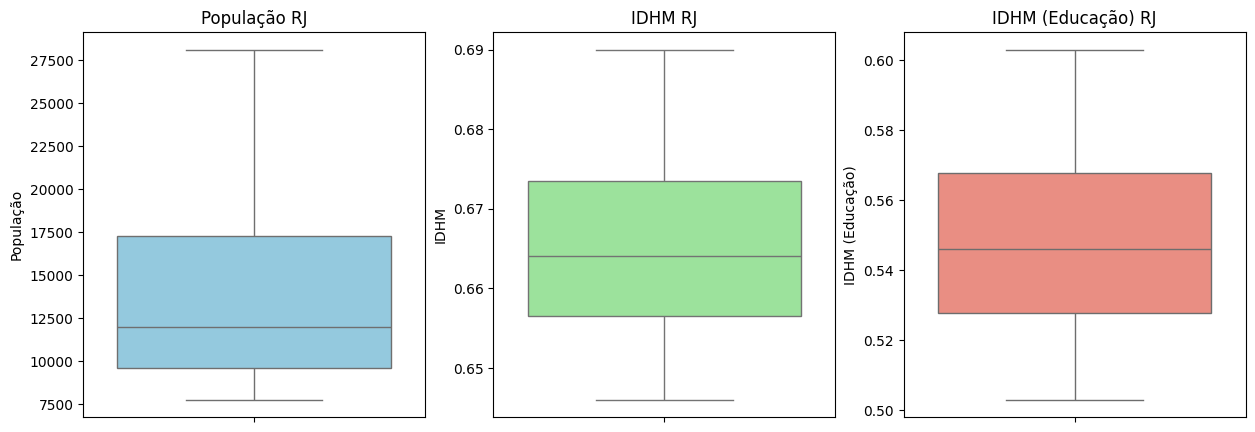

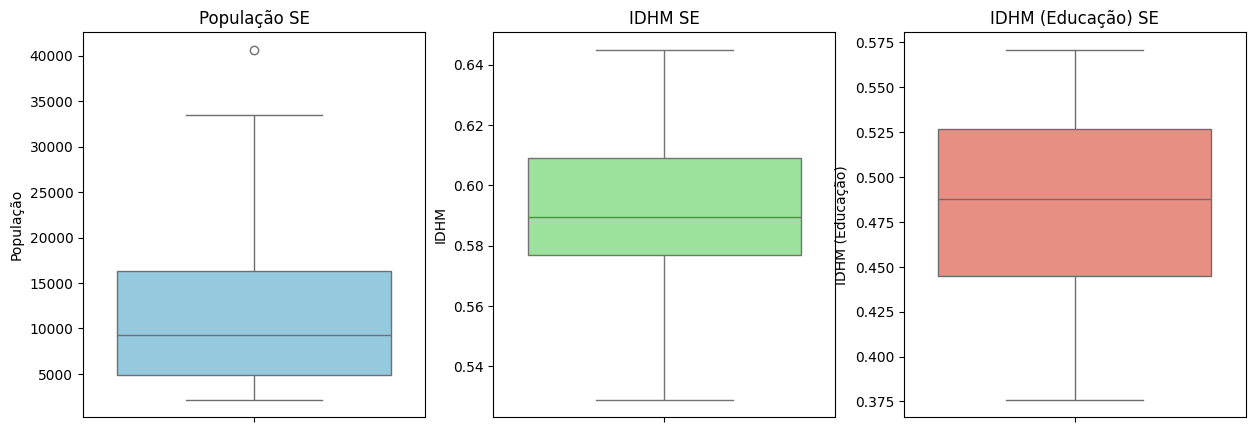

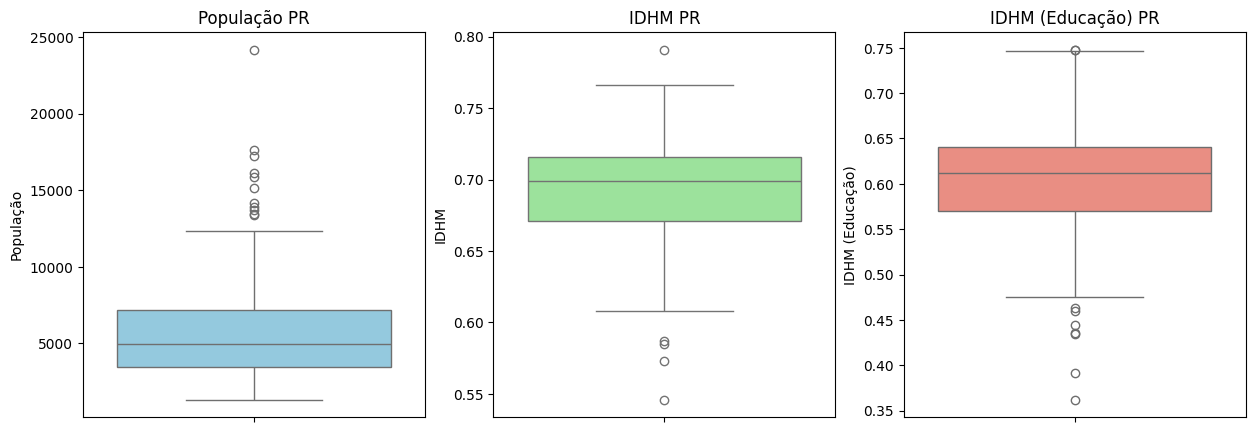

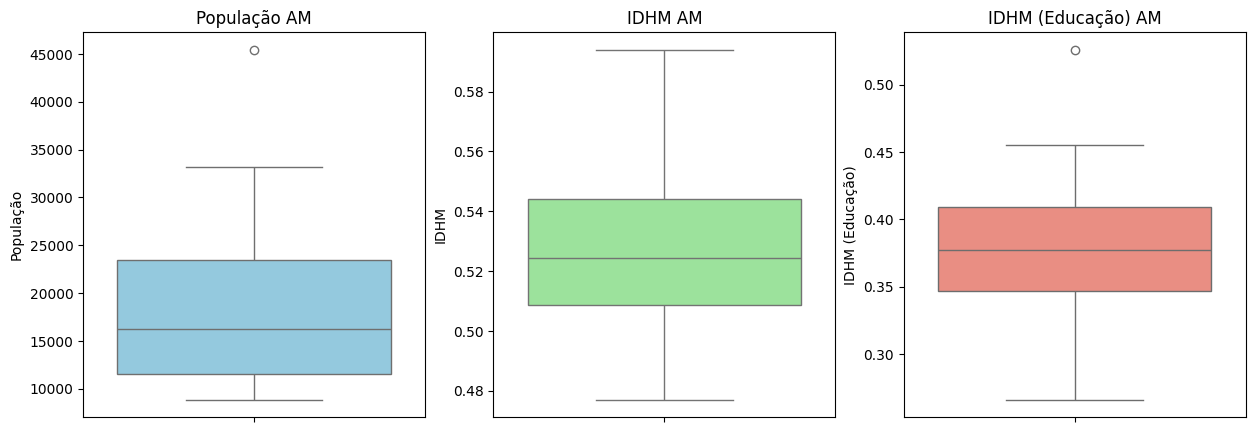

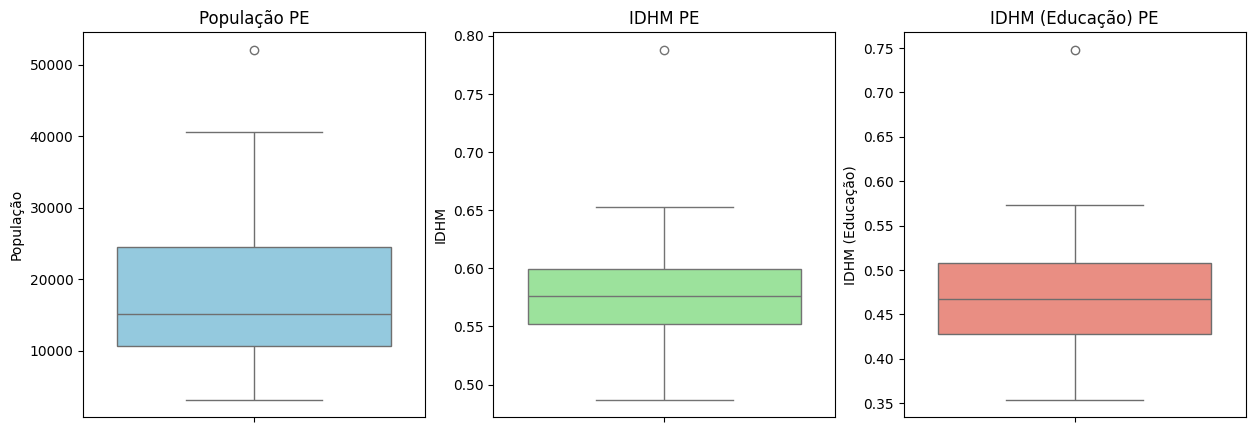

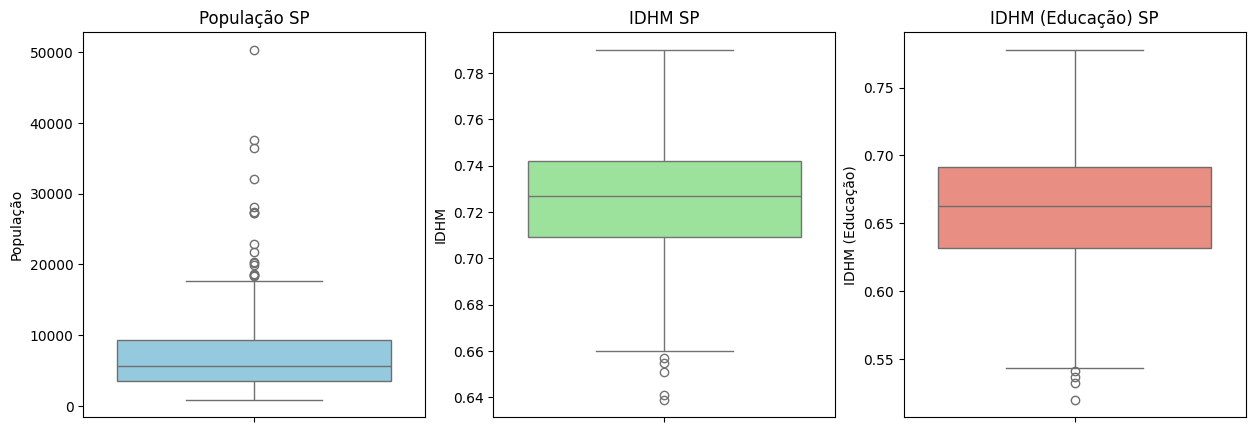

In [78]:
states = list(set([state for state in df['UF'].to_list()]))
for state in states:
    df_state = df[df['UF']==state]

    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    sns.boxplot(y=df_state['População'], ax=axes[0], color="skyblue")
    axes[0].set_title(f'População {state}')

    sns.boxplot(y=df_state['IDHM'], ax=axes[1], color="lightgreen")
    axes[1].set_title(f'IDHM {state}')

    sns.boxplot(y=df_state['IDHM (Educação)'], ax=axes[2], color="salmon")
    axes[2].set_title(f'IDHM (Educação) {state}')

    plt.show()